# 001 Orderbook Replay

**Загрузка из Parquet, проверка структуры и анимация стакана L10 во времени.**

- Загрузка реконструированного стакана из Parquet (`data/reconstructed/...`)
- Подготовка массивов bid/ask (цены, объёмы)
- Визуализация одного стакана (bids зелёные влево, asks красные вправо)
- Анимация динамики стакана через FuncAnimation

In [9]:
import sys
from pathlib import Path

import pandas as pd

# Root проекта
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
root = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
if (root / "research").is_dir():
    sys.path.insert(0, str(root))

data_dir = root / "data" / "reconstructed"

In [10]:
# Путь к Parquet (подставь свой файл)
# data_dir из первой ячейки (root / data / reconstructed) — выполни её

# Путь к одному часовому parquet
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Файл по умолчанию не найден, загружаю:", parquet_path)

df = pd.read_parquet(parquet_path)
df

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35996,2026-03-04 10:59:59.600000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,160.55,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35997,2026-03-04 10:59:59.700000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35998,2026-03-04 10:59:59.800000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00
35999,2026-03-04 10:59:59.900000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.80,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00


## 1. Подготовка данных для анимации стакана

In [11]:
import numpy as np

BID_PX = [f"bid_px_{i:02d}" for i in range(1, 11)]
BID_SZ = [f"bid_sz_{i:02d}" for i in range(1, 11)]
ASK_PX = [f"ask_px_{i:02d}" for i in range(1, 11)]
ASK_SZ = [f"ask_sz_{i:02d}" for i in range(1, 11)]

# Фиксированная ось объёма для анимации (макс. по всему df + запас)
max_bid_vol = df[BID_SZ].fillna(0).sum(axis=1).max()
max_ask_vol = df[ASK_SZ].fillna(0).sum(axis=1).max()
MAX_VOL = max(max_bid_vol, max_ask_vol) * 1.15  # 15% запас

row = df.iloc[0]
bid_prices = np.array([row[c] for c in BID_PX], dtype=float)
ask_prices = np.array([row[c] for c in ASK_PX], dtype=float)
bid_ok = ~np.isnan(bid_prices)
ask_ok = ~np.isnan(ask_prices)
bid_prices = bid_prices[bid_ok]
ask_prices = ask_prices[ask_ok]
bid_prices = np.sort(bid_prices)[::-1]
ask_prices = np.sort(ask_prices)

print("Bid prices (desc):", bid_prices[:3], "...")
print("Ask prices (asc):", ask_prices[:3], "...")

Bid prices (desc): [71492.4 71492.3 71492.2] ...
Ask prices (asc): [71492.5 71492.6 71494. ] ...


## 2. Функция построения одного стакана

In [12]:
import matplotlib.pyplot as plt


def plot_orderbook_snapshot(row, ax=None):
    """Bids слева (зелёные), asks справа (красные). Y=цена, X=объём."""
    if ax is None:
        ax = plt.gca()
    bid_prices = np.array([row[c] for c in BID_PX], dtype=float)
    bid_sizes = np.array([row[c] for c in BID_SZ], dtype=float)
    ask_prices = np.array([row[c] for c in ASK_PX], dtype=float)
    ask_sizes = np.array([row[c] for c in ASK_SZ], dtype=float)
    bid_ok = ~np.isnan(bid_prices) & ~np.isnan(bid_sizes)
    ask_ok = ~np.isnan(ask_prices) & ~np.isnan(ask_sizes)
    bid_prices, bid_sizes = bid_prices[bid_ok], bid_sizes[bid_ok]
    ask_prices, ask_sizes = ask_prices[ask_ok], ask_sizes[ask_ok]
    bid_idx = np.argsort(-bid_prices)
    ask_idx = np.argsort(ask_prices)
    bid_prices, bid_sizes = bid_prices[bid_idx], bid_sizes[bid_idx]
    ask_prices, ask_sizes = ask_prices[ask_idx], ask_sizes[ask_idx]
    mid = row["mid_px"]
    spread = row.get("spread_px", 0.1)
    margin = abs(float(spread)) * 3
    y_min = (bid_prices.min() - margin) if len(bid_prices) else mid - 1
    y_max = (ask_prices.max() + margin) if len(ask_prices) else mid + 1
    # Фиксированная ось Volume: -600 .. 0 .. +600
    ax.set_xlim(-600, 600)
    # Высота столбцов — чтобы 20 уровней не сливались
    bar_height = (y_max - y_min) / 50
    bars_bid = ax.barh(bid_prices, -bid_sizes, color="green", alpha=0.85, height=bar_height, edgecolor="darkgreen", linewidth=0.5)
    bars_ask = ax.barh(ask_prices, ask_sizes, color="red", alpha=0.85, height=bar_height, edgecolor="darkred", linewidth=0.5)
    ax.bar_label(bars_bid, labels=[f"{s:.1f}" for s in bid_sizes], fontsize=9, padding=4, label_type="center")
    ax.bar_label(bars_ask, labels=[f"{s:.1f}" for s in ask_sizes], fontsize=9, padding=4, label_type="center")
    ax.axvline(0, color="black", linewidth=1)
    ax.axhline(mid, color="blue", linewidth=1, linestyle="--", label=f"Mid {mid:.2f}")
    ax.set_xlabel("Volume")
    ax.set_ylabel("Price")
    ax.set_ylim(y_min, y_max)
    ax.legend(loc="upper right")

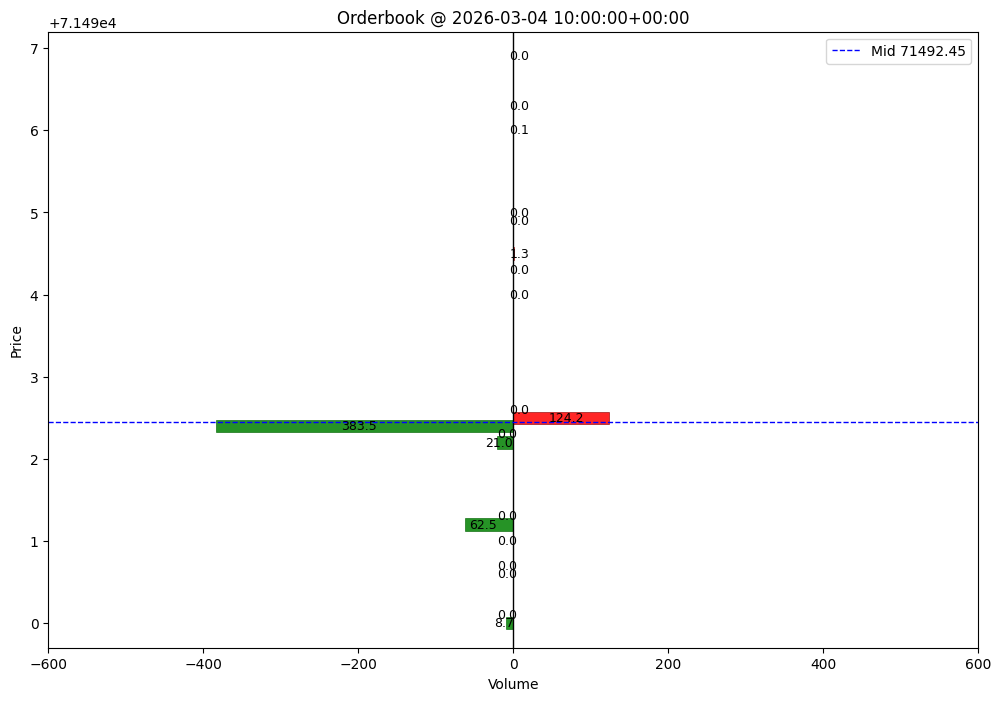

In [ ]:
# Превью: один кадр стакана
fig, ax = plt.subplots(figsize=(12, 8))
plot_orderbook_snapshot(df.iloc[0], ax=ax)
ax.set_title(f"Orderbook @ {df.iloc[0]['ts_event']}")
plt.show()

## 3. Анимация динамики стакана

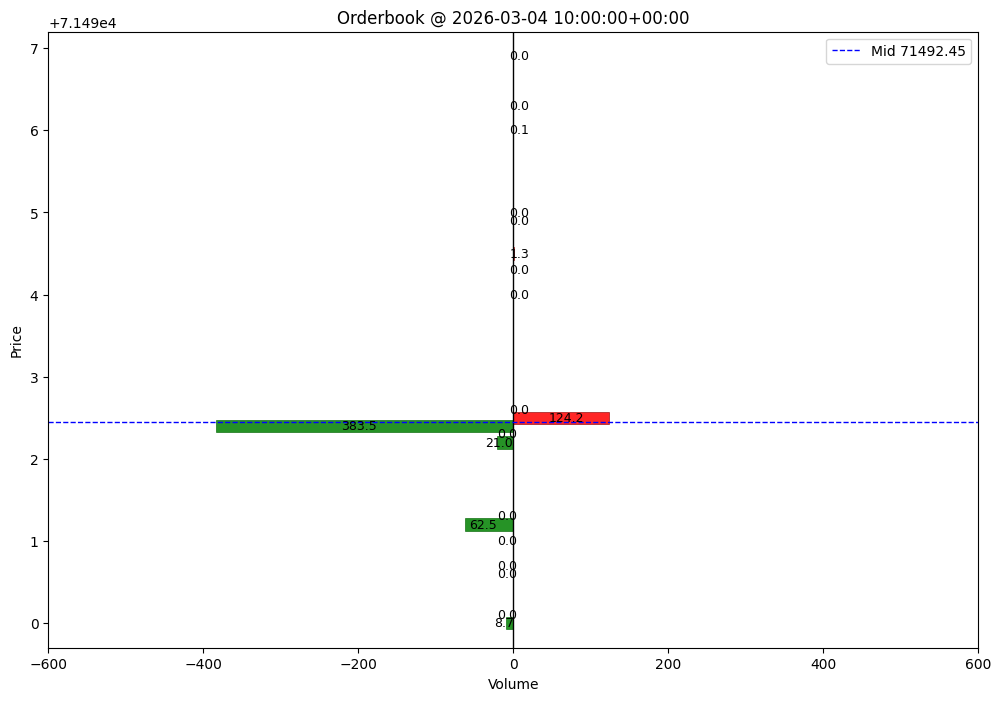

In [14]:
import matplotlib
from matplotlib.animation import FuncAnimation

matplotlib.rcParams["animation.embed_limit"] = 100  # MB (для больших анимаций)

STEP = 1  # каждый N-й кадр (меньше кадров — быстрее анимация)
indices = np.arange(0, len(df), STEP)


def animate(i):
    ax.clear()
    idx = indices[i]
    row = df.iloc[idx]
    plot_orderbook_snapshot(row, ax=ax)
    ts = row["ts_event"]
    ax.set_title(f"Orderbook @ {ts}")


fig, ax = plt.subplots(figsize=(12, 8))
anim = FuncAnimation(fig, animate, frames=len(indices), interval=80, repeat=True)

## 4. Запуск анимации

In [15]:
#from IPython.display import HTML

#HTML(anim.to_jshtml())